<a href="https://colab.research.google.com/github/pranavvup-byte/ml-pratical-week/blob/main/pratical_week_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (50000, 21)

Hierarchical Clustering
-----------------------
Clusters: 3
Silhouette Score: 0.2517

DBSCAN
------
Number of clusters: 1
Noise points: 0


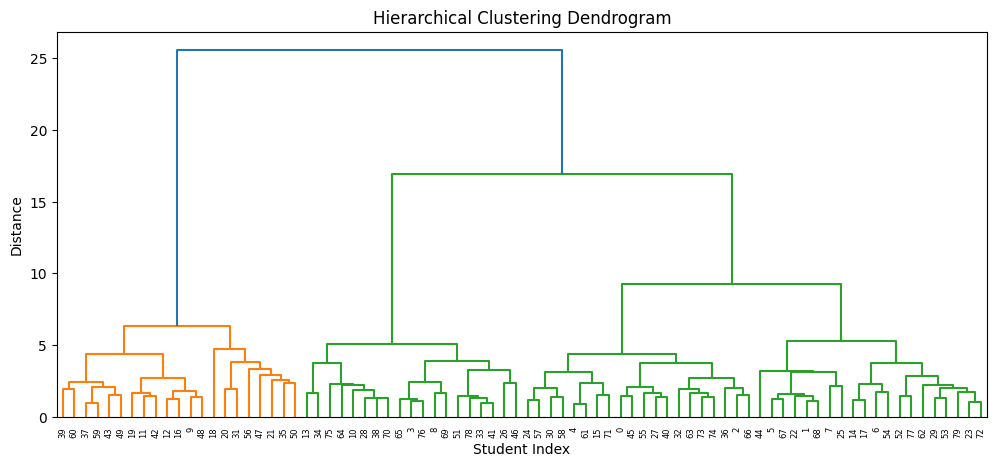

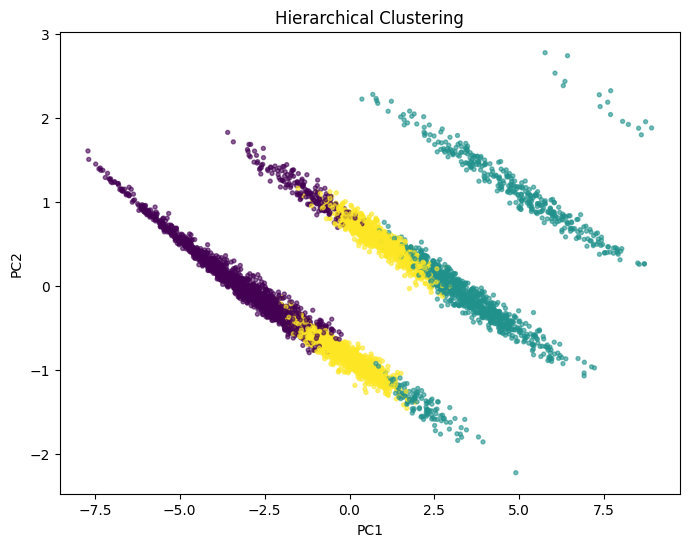

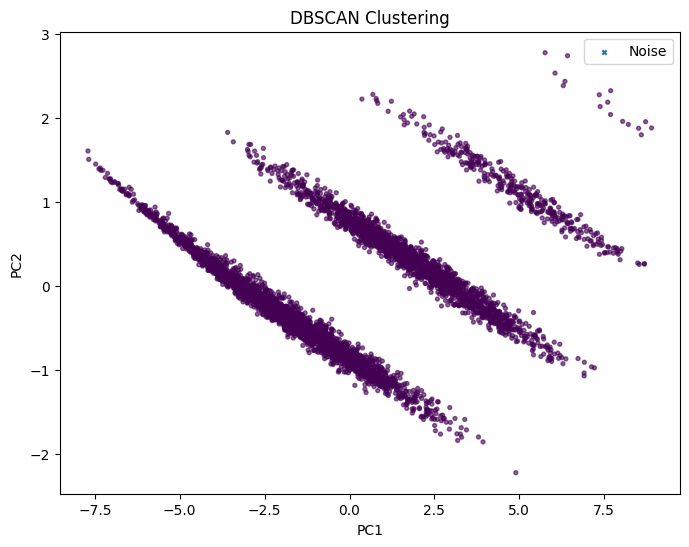

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage


# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------

df = pd.read_csv(
    "/content/placement_predict_50k_adjusted (1).csv"
)

print("Dataset shape:", df.shape)


# --------------------------------------------------
# 2. Select numerical features
# --------------------------------------------------

numeric_cols = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]


# --------------------------------------------------
# 3. Handle missing values
# --------------------------------------------------

imputer = SimpleImputer(
    strategy="median"
)

X_numeric = imputer.fit_transform(
    df[numeric_cols]
)


# --------------------------------------------------
# 4. Standardize
# --------------------------------------------------

scaler = StandardScaler()

X = scaler.fit_transform(
    X_numeric
)


# --------------------------------------------------
# 5. Use a 5000-student sample
# --------------------------------------------------

np.random.seed(42)

sample_size = 5000

sample_indices = np.random.choice(
    len(X),
    sample_size,
    replace=False
)

X_sample = X[sample_indices]


# --------------------------------------------------
# 6. Hierarchical Clustering
# --------------------------------------------------

best_k = 3

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_sample
)

hierarchical_silhouette = silhouette_score(
    X_sample,
    hierarchical_labels
)

print("\nHierarchical Clustering")
print("-----------------------")
print("Clusters:", best_k)
print(
    "Silhouette Score:",
    round(hierarchical_silhouette, 4)
)


# --------------------------------------------------
# 7. DBSCAN
# --------------------------------------------------

dbscan = DBSCAN(
    eps=4.0,
    min_samples=15
)

dbscan_labels = dbscan.fit_predict(
    X_sample
)


# Number of clusters
number_of_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)


# Number of noise points
number_of_noise = np.sum(
    dbscan_labels == -1
)

print("\nDBSCAN")
print("------")

print(
    "Number of clusters:",
    number_of_clusters
)

print(
    "Noise points:",
    number_of_noise
)


# --------------------------------------------------
# 8. DBSCAN silhouette
# --------------------------------------------------

if number_of_clusters >= 2:

    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        X_sample[mask],
        dbscan_labels[mask]
    )

    print(
        "Silhouette Score:",
        round(dbscan_silhouette, 4)
    )


# --------------------------------------------------
# 9. Dendrogram
# --------------------------------------------------

dendrogram_sample = np.random.choice(
    len(X_sample),
    min(80, len(X_sample)),
    replace=False
)

Z = linkage(
    X_sample[dendrogram_sample],
    method="ward"
)

plt.figure(figsize=(12, 5))

dendrogram(Z)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Student Index")
plt.ylabel("Distance")

plt.show()


# --------------------------------------------------
# 10. PCA visualization
# --------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)


# Hierarchical
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    s=8,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering")

plt.show()


# DBSCAN
plt.figure(figsize=(8, 6))

noise = dbscan_labels == -1

plt.scatter(
    X_pca[~noise, 0],
    X_pca[~noise, 1],
    c=dbscan_labels[~noise],
    s=8,
    alpha=0.6
)

plt.scatter(
    X_pca[noise, 0],
    X_pca[noise, 1],
    s=10,
    marker="x",
    label="Noise"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering")

plt.legend()

plt.show()